In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [60]:
df=pd.read_csv("stock_prices.csv")

In [61]:
df.head()

,Days,Price
0,1,205.467142
1,2,199.617357
2,3,207.976885
3,4,217.230299
4,5,200.158466


Text(0, 0.5, 'Price')

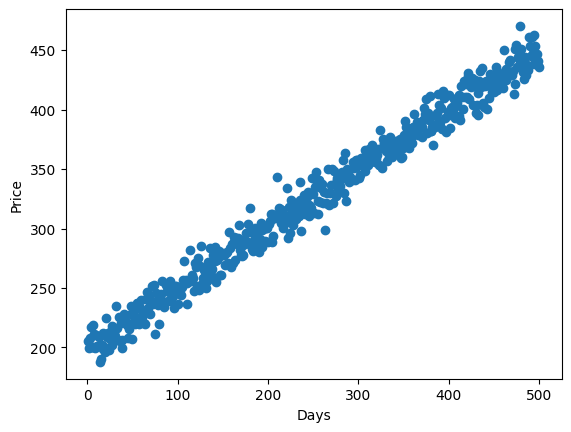

In [62]:
## scatter plot
plt.scatter(df['Days'],df['Price'])
plt.xlabel('Days')
plt.ylabel('Price')

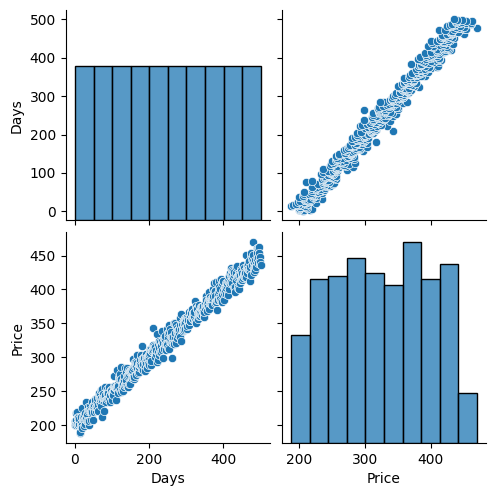

In [63]:
## seaborn visualization
import seaborn as sns
sns.pairplot(df)

In [64]:
##independent and dependent features
X=df[['Days']] 
y=df['Price'] 

In [65]:
## Train Test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [66]:
## standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [67]:
## apply simple linear regression algo
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [68]:
print("coefficient or slope:",regression.coef_)

coefficient or slope: [70.76375354]


In [69]:
print("intercept:",regression.intercept_)

intercept: 325.10255357661816


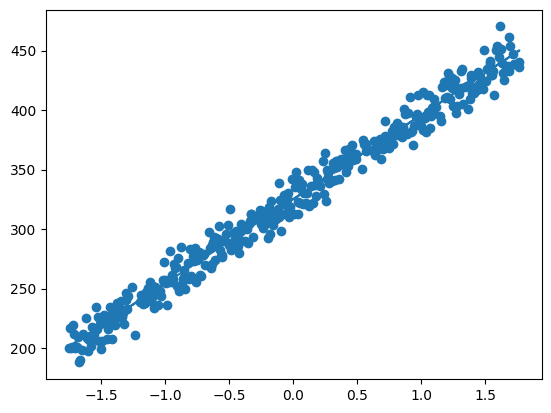

In [70]:
## plot training data and plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [71]:
## prediction for test data
y_pred=regression.predict(X_test)

In [72]:
## performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)


89.29564554527185
7.005987432186325
9.44963732347818


In [73]:
## R squared
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.9851741413659092


In [74]:
## display adjusted R square
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.9850536059298597

In [75]:
new_data = pd.DataFrame({'Days': [4]})

# Scale and predict safely (no warnings)
predicted_score = regression.predict(scaler.transform(new_data))
print(predicted_score)

[201.95520351]
